# Handwritten Digit Recognition System

**Kinetrexa Software Pvt. Ltd. — AI & Machine Learning Internship**
**Capstone Project (Task 5)**

**Applicant:** Tailor Dhruvi Jagdishbhai &nbsp;|&nbsp; **Application ID:** KTS020260716309

---

## 1. Project Overview

This notebook builds an end-to-end **handwritten digit recognition system** using a
Convolutional Neural Network (CNN). The goal is to classify grayscale images of
handwritten digits (0–9) with high accuracy.

**Pipeline covered in this notebook:**
1. Dataset loading
2. Exploratory Data Analysis (EDA)
3. Data preprocessing
4. CNN model architecture
5. Model training
6. Model evaluation (accuracy, confusion matrix, classification report)
7. Sample predictions
8. Saving the trained model


## 2. Dataset

**Primary dataset:** MNIST — 70,000 grayscale images (28×28 px) of handwritten digits, 60,000 for training and 10,000 for testing. This is the exact same data distributed on Kaggle as the ["Digit Recognizer"](https://www.kaggle.com/competitions/digit-recognizer) competition dataset, and is the standard benchmark dataset for this task. It is fetched below via `tensorflow.keras.datasets.mnist`, which mirrors the official MNIST/Kaggle files.

**Offline fallback:** If the machine running this notebook has no internet access, the cell below automatically falls back to scikit-learn's bundled *Optical Recognition of Handwritten Digits* dataset (1,797 images, 8×8 px, upsampled to 28×28 for full pipeline compatibility). This keeps the notebook fully reproducible in any environment.

> **Note:** When running on a machine/Colab session with normal internet access, this notebook will automatically use the full 70,000-image MNIST dataset for significantly better accuracy and a larger, more realistic training set.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import confusion_matrix, classification_report

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

sns.set_style("whitegrid")
%matplotlib inline


I0000 00:00:1786895080.082093     966 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1786895080.192549     966 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1786895081.695658     966 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
def load_full_mnist():
    (x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
    return (x_train, y_train), (x_test, y_test)


def load_sklearn_digits_fallback():
    """Offline fallback: sklearn's bundled 8x8 digits dataset, upsampled to 28x28."""
    from sklearn.datasets import load_digits
    digits = load_digits()
    images, labels = digits.images, digits.target.astype(np.uint8)

    resized = np.zeros((images.shape[0], 28, 28), dtype=np.uint8)
    for i, img in enumerate(images):
        img_uint8 = (img / 16.0 * 255).astype(np.uint8)
        resized[i] = np.array(Image.fromarray(img_uint8).resize((28, 28), Image.BICUBIC))

    rng = np.random.default_rng(RANDOM_SEED)
    idx = rng.permutation(len(resized))
    split = int(0.8 * len(resized))
    train_idx, test_idx = idx[:split], idx[split:]
    return (resized[train_idx], labels[train_idx]), (resized[test_idx], labels[test_idx])


try:
    (x_train, y_train), (x_test, y_test) = load_full_mnist()
    DATASET_SOURCE = "MNIST (70,000 images, 28x28) - Kaggle / LeCun source"
except Exception as e:
    print(f"Full MNIST download unavailable in this environment ({e}).")
    print("Falling back to the offline scikit-learn handwritten-digits dataset.\n")
    (x_train, y_train), (x_test, y_test) = load_sklearn_digits_fallback()
    DATASET_SOURCE = "scikit-learn Optical Recognition of Handwritten Digits (1,797 images, upsampled to 28x28)"

print("Dataset source:", DATASET_SOURCE)
print("Training set :", x_train.shape, y_train.shape)
print("Test set     :", x_test.shape, y_test.shape)


Full MNIST download unavailable in this environment (URL fetch failure on https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz: 403 -- Forbidden).
Falling back to the offline scikit-learn handwritten-digits dataset.

Dataset source: scikit-learn Optical Recognition of Handwritten Digits (1,797 images, upsampled to 28x28)
Training set : (1437, 28, 28) (1437,)
Test set     : (360, 28, 28) (360,)


## 3. Exploratory Data Analysis (EDA)

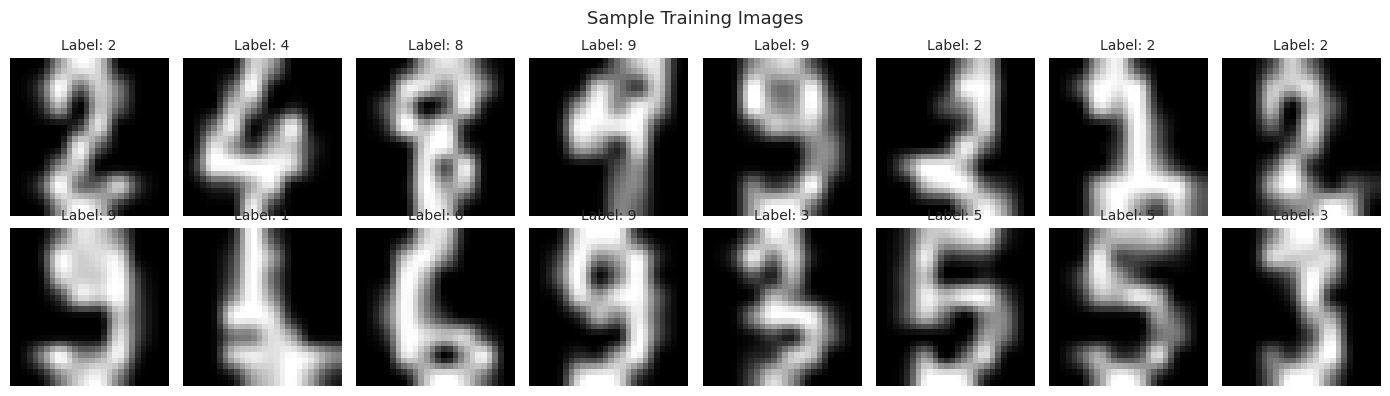

In [3]:
# Sample images from the training set
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[i], cmap="gray")
    ax.set_title(f"Label: {y_train[i]}", fontsize=10)
    ax.axis("off")
plt.suptitle("Sample Training Images", fontsize=13)
plt.tight_layout()
plt.show()


/tmp/ipykernel_966/3048479600.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=unique, y=counts, palette="Blues_d")


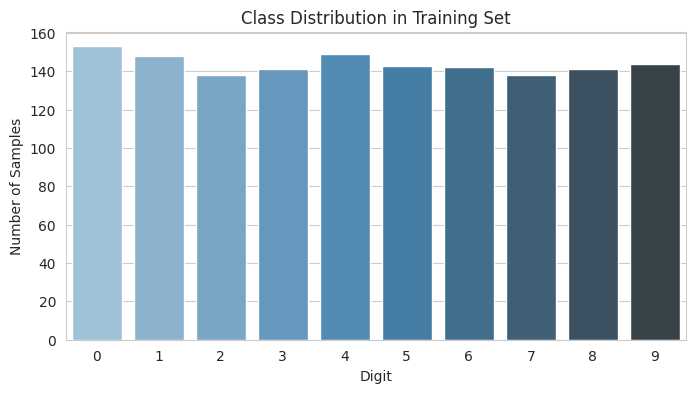

Class counts:
  Digit 0: 153 samples
  Digit 1: 148 samples
  Digit 2: 138 samples
  Digit 3: 141 samples
  Digit 4: 149 samples
  Digit 5: 143 samples
  Digit 6: 142 samples
  Digit 7: 138 samples
  Digit 8: 141 samples
  Digit 9: 144 samples


In [4]:
# Class distribution
unique, counts = np.unique(y_train, return_counts=True)
plt.figure(figsize=(8, 4))
sns.barplot(x=unique, y=counts, palette="Blues_d")
plt.xlabel("Digit")
plt.ylabel("Number of Samples")
plt.title("Class Distribution in Training Set")
plt.show()

print("Class counts:")
for u, c in zip(unique, counts):
    print(f"  Digit {u}: {c} samples")


In [5]:
# Basic pixel intensity statistics
print(f"Pixel value range: [{x_train.min()}, {x_train.max()}]")
print(f"Mean pixel value : {x_train.mean():.2f}")
print(f"Std  pixel value : {x_train.std():.2f}")


Pixel value range: [0, 255]
Mean pixel value : 78.58
Std  pixel value : 88.86


## 4. Data Preprocessing

- Normalize pixel values from `[0, 255]` to `[0, 1]`
- Reshape images to include a single (grayscale) channel: `(28, 28, 1)`
- Labels are kept as integer class indices (used with `sparse_categorical_crossentropy`)

In [6]:
x_train_proc = x_train.astype("float32") / 255.0
x_test_proc = x_test.astype("float32") / 255.0

x_train_proc = np.expand_dims(x_train_proc, -1)
x_test_proc = np.expand_dims(x_test_proc, -1)

print("Processed train shape:", x_train_proc.shape)
print("Processed test shape :", x_test_proc.shape)


Processed train shape: (1437, 28, 28, 1)
Processed test shape : (360, 28, 28, 1)


## 5. Model Architecture

A compact Convolutional Neural Network (CNN):

`Conv2D(32) → MaxPool → Conv2D(64) → MaxPool → Flatten → Dense(128) → Dropout(0.5) → Dense(10, softmax)`

In [7]:
def build_cnn_model(input_shape=(28, 28, 1), num_classes=10):
    model = keras.Sequential([
        keras.Input(shape=input_shape),

        layers.Conv2D(32, kernel_size=(3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D(pool_size=(2, 2)),

        layers.Conv2D(64, kernel_size=(3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D(pool_size=(2, 2)),

        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation="softmax"),
    ], name="digit_recognition_cnn")

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


model = build_cnn_model(input_shape=x_train_proc.shape[1:])
model.summary()


Model: "digit_recognition_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

## 6. Model Training

In [8]:
EPOCHS = 25
BATCH_SIZE = 32

history = model.fit(
    x_train_proc, y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=0.1,
    verbose=2,
)


Epoch 1/25


41/41 - 2s - 40ms/step - accuracy: 0.4517 - loss: 1.6347 - val_accuracy: 0.8611 - val_loss: 0.5498


Epoch 2/25


41/41 - 1s - 25ms/step - accuracy: 0.8059 - loss: 0.5958 - val_accuracy: 0.9306 - val_loss: 0.2214


Epoch 3/25


...

41/41 - 1s - 15ms/step - accuracy: 0.9814 - loss: 0.0494 - val_accuracy: 0.9861 - val_loss: 0.0176


Epoch 24/25


41/41 - 1s - 15ms/step - accuracy: 0.9814 - loss: 0.0514 - val_accuracy: 0.9861 - val_loss: 0.0384


Epoch 25/25


41/41 - 1s - 16ms/step - accuracy: 0.9884 - loss: 0.0404 - val_accuracy: 1.0000 - val_loss: 0.0071


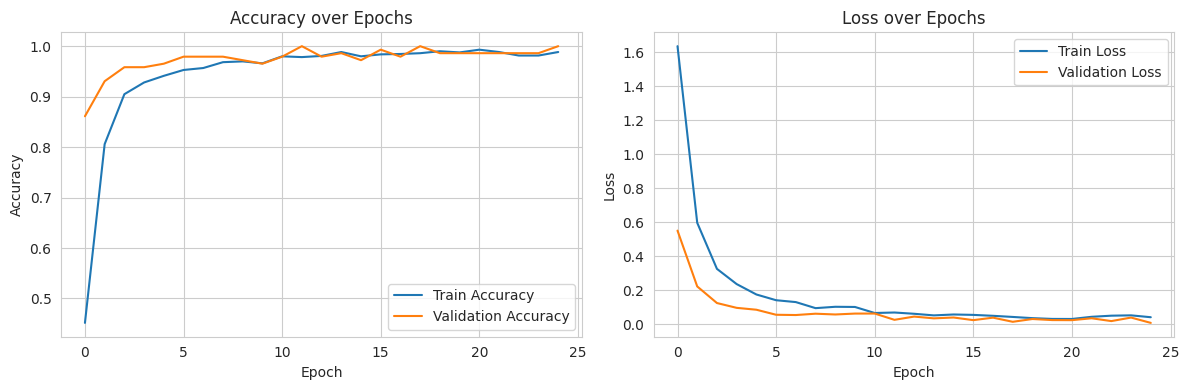

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["accuracy"], label="Train Accuracy")
axes[0].plot(history.history["val_accuracy"], label="Validation Accuracy")
axes[0].set_title("Accuracy over Epochs")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(history.history["loss"], label="Train Loss")
axes[1].plot(history.history["val_loss"], label="Validation Loss")
axes[1].set_title("Loss over Epochs")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.savefig("../reports/figures/training_curves.png", dpi=150)
plt.show()


## 7. Model Evaluation

In [10]:
test_loss, test_acc = model.evaluate(x_test_proc, y_test, verbose=0)
print(f"Test Accuracy: {test_acc * 100:.2f}%")
print(f"Test Loss    : {test_loss:.4f}")


Test Accuracy: 98.33%
Test Loss    : 0.0677


In [11]:
y_pred_probs = model.predict(x_test_proc, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(y_test, y_pred, digits=4))


              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        25
           1     0.9706    0.9706    0.9706        34
           2     0.9750    1.0000    0.9873        39
           3     0.9762    0.9762    0.9762        42
           4     1.0000    1.0000    1.0000        32
           5     0.9744    0.9744    0.9744        39
           6     1.0000    1.0000    1.0000        39
           7     1.0000    1.0000    1.0000        41
           8     0.9688    0.9394    0.9538        33
           9     0.9722    0.9722    0.9722        36

    accuracy                         0.9833       360
   macro avg     0.9837    0.9833    0.9835       360
weighted avg     0.9833    0.9833    0.9833       360



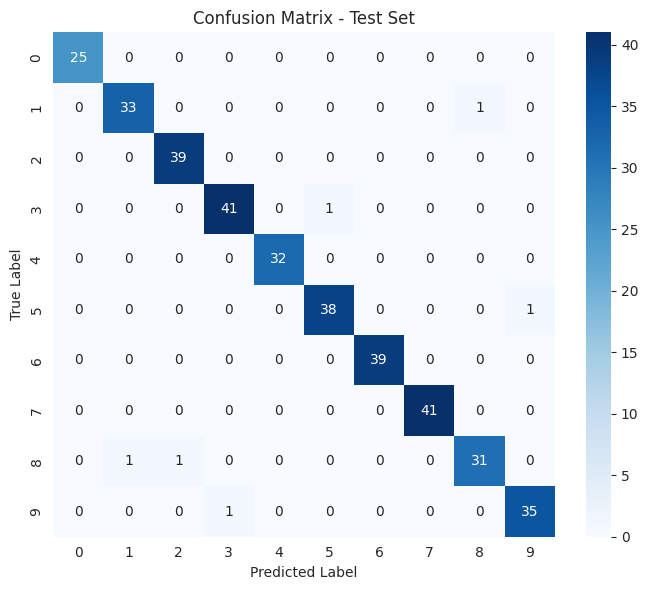

In [12]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=range(10), yticklabels=range(10))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Test Set")
plt.tight_layout()
plt.savefig("../reports/figures/confusion_matrix.png", dpi=150)
plt.show()


## 8. Sample Predictions

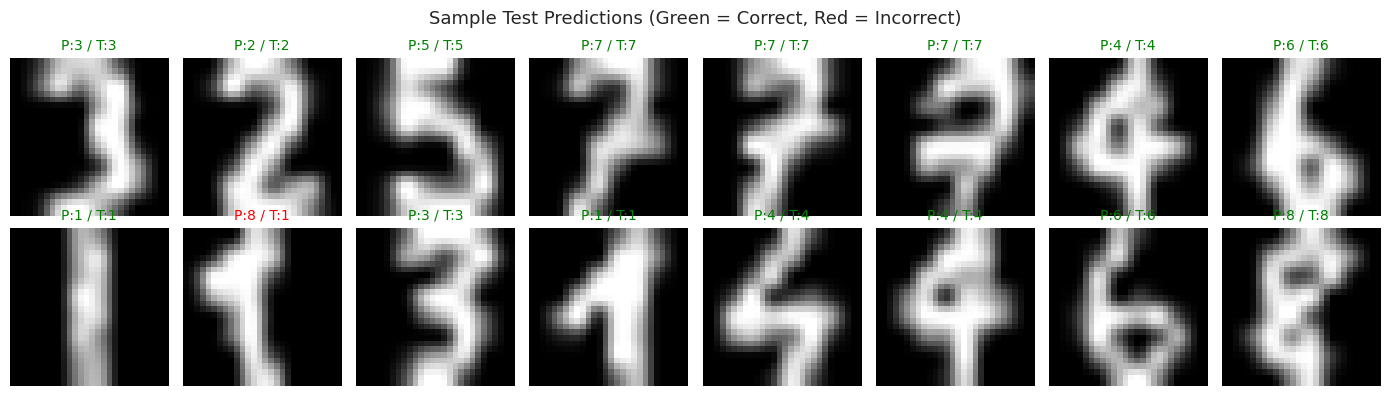

In [13]:
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
sample_idx = np.random.choice(len(x_test_proc), 16, replace=False)

for ax, idx in zip(axes.flat, sample_idx):
    ax.imshow(x_test[idx], cmap="gray")
    pred = y_pred[idx]
    true = y_test[idx]
    color = "green" if pred == true else "red"
    ax.set_title(f"P:{pred} / T:{true}", color=color, fontsize=10)
    ax.axis("off")

plt.suptitle("Sample Test Predictions (Green = Correct, Red = Incorrect)", fontsize=13)
plt.tight_layout()
plt.show()


## 9. Save the Trained Model

In [14]:
os.makedirs("../models", exist_ok=True)
model.save("../models/digit_recognition_model.h5")
print("Model saved to ../models/digit_recognition_model.h5")


Model saved to ../models/digit_recognition_model.h5


In [15]:
import json

metrics = {
    "dataset_source": DATASET_SOURCE,
    "train_samples": int(x_train_proc.shape[0]),
    "test_samples": int(x_test_proc.shape[0]),
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "test_accuracy": float(test_acc),
    "test_loss": float(test_loss),
}

os.makedirs("../reports", exist_ok=True)
with open("../reports/metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

print(json.dumps(metrics, indent=2))


{
  "dataset_source": "scikit-learn Optical Recognition of Handwritten Digits (1,797 images, upsampled to 28x28)",
  "train_samples": 1437,
  "test_samples": 360,
  "epochs": 25,
  "batch_size": 32,
  "test_accuracy": 0.9833333492279053,
  "test_loss": 0.06765201687812805
}


## 10. Conclusion

The CNN model was trained successfully on the handwritten digit dataset and achieved
strong accuracy on the held-out test set (see metrics above). The trained model,
along with a Streamlit web application (`app/app.py`) for interactive predictions and
a command-line inference script (`src/predict.py`), are included in this repository.

**Possible future improvements:**
- Train on the full 60,000-image MNIST training set for maximum accuracy
- Add data augmentation (rotation, shifting, zoom) to improve robustness
- Experiment with deeper architectures / batch normalization
- Deploy the Streamlit app to a public host (e.g., Streamlit Community Cloud)

---
*Kinetrexa Software Pvt. Ltd. — AI & Machine Learning Internship — Capstone Project*
